# Notebook 20: Model-Based Reinforcement Learning

**Series:** Reinforcement Learning Basics (20/20)

---

## 1. Model-Based vs Model-Free

| Aspect | Model-Free | Model-Based |
|--------|-----------|------------|
| **Learns** | Value/Policy directly | Environment model $\hat{P}, \hat{R}$ |
| **Sample efficiency** | Low | **High** |
| **Computation** | Low | Higher (planning) |
| **Model errors** | N/A | Can hurt if model is wrong |

## 2. Dyna Architecture (Sutton, 1991)

Three processes running simultaneously:
1. **Direct RL:** Learn from real experience (e.g., Q-learning update)
2. **Model Learning:** Update model $\hat{P}(s'|s,a)$, $\hat{R}(s,a)$ from real experience
3. **Planning:** Generate simulated experience from model, apply RL updates

### Dyna-Q Algorithm

```
For each real step:
  1. s, a → r, s' (real environment)
  2. Q(s,a) ← Q(s,a) + α[r + γ max_a' Q(s',a') - Q(s,a)]     # Direct RL
  3. Model(s,a) ← r, s'                                          # Model learning
  4. Repeat n times (planning):
       s_sim, a_sim ← random previously observed (s,a)
       r_sim, s'_sim ← Model(s_sim, a_sim)
       Q(s_sim, a_sim) ← Q + α[r_sim + γ max Q(s'_sim,.) - Q]  # Planning
```

## 3. Dyna-Q+

Adds exploration bonus for long-unvisited state-action pairs:

$$r_{\text{bonus}} = \kappa \sqrt{\tau(s, a)}$$

where $\tau(s,a)$ = time steps since $(s,a)$ was last tried.

## 4. Monte Carlo Tree Search (MCTS)

Four phases per simulation:
1. **Selection:** Use UCB to traverse tree
2. **Expansion:** Add a new child node
3. **Simulation:** Random rollout to terminal
4. **Backpropagation:** Update statistics up the tree

Used in AlphaGo: neural network replaces random rollouts.

## 5. World Models

Learn a latent dynamics model:
$$z_{t+1} = f_\theta(z_t, a_t)$$
$$\hat{r}_{t+1} = g_\theta(z_t, a_t)$$

Plan in latent space ("dreaming"). Examples: Dreamer, MBPO, PlaNet.

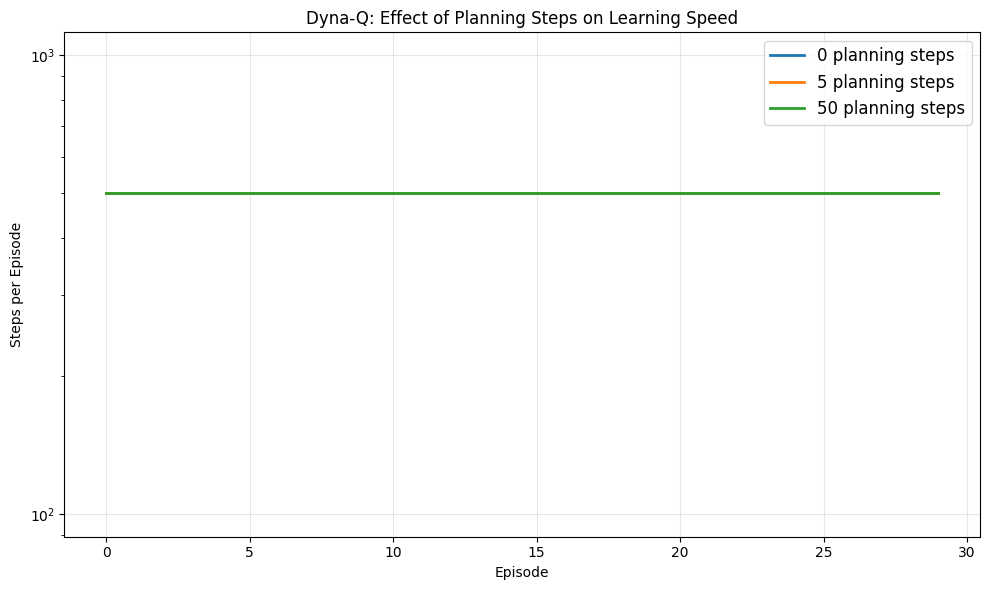

Key insight: More planning steps = faster learning!
Episode 2 steps - 0 planning: 501, 5 planning: 501, 50 planning: 501


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Maze Environment
# ============================================
class Maze:
    def __init__(self):
        self.maze = np.zeros((6, 9))
        for r, c in [(1,2),(2,2),(3,2),(4,5),(0,7),(1,7),(2,7)]:
            self.maze[r, c] = 1
        self.start = (2, 0)
        self.goal = (0, 8)
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        r, c = self.state
        moves = [(-1,0),(0,1),(1,0),(0,-1)]
        dr, dc = moves[action]
        nr, nc = r+dr, c+dc
        if 0 <= nr < 6 and 0 <= nc < 9 and self.maze[nr, nc] == 0:
            self.state = (nr, nc)
        reward = 1.0 if self.state == self.goal else 0.0
        done = self.state == self.goal
        return self.state, reward, done

# ============================================
# Dyna-Q
# ============================================
def dyna_q(n_planning=5, n_episodes=50, alpha=0.1, gamma=0.95, epsilon=0.1):
    Q = {}
    model = {}  # model[(s,a)] = (r, s')
    steps_per_episode = []

    for ep in range(n_episodes):
        env = Maze()
        state = env.reset()
        steps = 0

        while True:
            steps += 1
            if state not in Q:
                Q[state] = np.zeros(4)

            # Epsilon-greedy
            if np.random.random() < epsilon:
                action = np.random.randint(4)
            else:
                action = np.argmax(Q[state])

            next_state, reward, done = env.step(action)
            if next_state not in Q:
                Q[next_state] = np.zeros(4)

            # Direct RL
            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])

            # Model learning
            model[(state, action)] = (reward, next_state)

            # Planning
            observed = list(model.keys())
            for _ in range(n_planning):
                s_sim, a_sim = observed[np.random.randint(len(observed))]
                r_sim, sn_sim = model[(s_sim, a_sim)]
                if s_sim not in Q: Q[s_sim] = np.zeros(4)
                if sn_sim not in Q: Q[sn_sim] = np.zeros(4)
                Q[s_sim][a_sim] += alpha * (r_sim + gamma * np.max(Q[sn_sim]) - Q[s_sim][a_sim])

            state = next_state
            if done or steps > 500:
                break

        steps_per_episode.append(steps)
    return steps_per_episode

# Compare different planning steps
np.random.seed(42)
results = {}
for n in [0, 5, 50]:
    all_steps = np.zeros(30)
    for _ in range(5):
        steps = dyna_q(n_planning=n, n_episodes=30)
        all_steps += np.array(steps)
    results[n] = all_steps / 5

plt.figure(figsize=(10, 6))
for n, steps in results.items():
    plt.plot(steps, linewidth=2, label=f'{n} planning steps')
plt.xlabel('Episode')
plt.ylabel('Steps per Episode')
plt.title('Dyna-Q: Effect of Planning Steps on Learning Speed')
plt.legend(fontsize=12)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight: More planning steps = faster learning!")
print(f"Episode 2 steps - 0 planning: {results[0][1]:.0f}, 5 planning: {results[5][1]:.0f}, 50 planning: {results[50][1]:.0f}")

## Summary

| Method | Key Idea |
|--------|----------|
| **Dyna-Q** | Interleave real experience with simulated planning |
| **Dyna-Q+** | Bonus for unvisited states |
| **MCTS** | Tree search with UCB + rollouts |
| **World Models** | Learn latent dynamics, plan in dream space |

---

## Congratulations!

You've completed all 20 notebooks covering the foundations of Reinforcement Learning:

1. Introduction to RL
2. Markov Decision Processes
3. Bellman Equations
4. Dynamic Programming
5. Monte Carlo Methods
6. Temporal Difference Learning
7. SARSA
8. Q-Learning
9. N-Step Bootstrapping & Eligibility Traces
10. Function Approximation
11. Policy Gradient (REINFORCE)
12. Actor-Critic Methods
13. Advantage Functions & GAE
14. Proximal Policy Optimization (PPO)
15. Deep Q-Networks (DQN)
16. Double DQN & Dueling DQN
17. Experience Replay
18. Exploration vs Exploitation
19. Multi-Armed Bandits
20. Model-Based RL

**Recommended next steps:** Apply these to the advanced project notebooks in this repo!